# Airfoil Optimization using NeuralFoil

In this tutorial, we'll use AeroSandbox for airfoil shape optimization, with aerodynamic, structural, and manufacturability constraints.

## A Brief Introduction to Airfoil Parameterization with `asb.KulfanAirfoil`

To do airfoil optimization (or at least, to do it well), we need to introduce a new class: `asb.KulfanAirfoil`.

`asb.KulfanAirfoil` is a subclass of `asb.Airfoil` (i.e., for the most part, it can do all the same things), except that the underlying parameterization is not a coordinate array, but rather a set of Kulfan (sometimes also called "CST") parameters. These Kulfan parameters correspond to the strengths of various mode shapes, which then are combined linearly to obtain a given airfoil shape.

* For more information on this Kulfan (CST) parameterization, see Brenda Kulfan's papers:
    * [Kulfan, Brenda, "Universal Parametric Geometry Representation Method", 2008](https://www.brendakulfan.com/_files/ugd/169bff_6738e0f8d9074610942c53dfaea8e30c.pdf)
    * [Kulfan, Brenda, "Modification of CST Airfoil Representation Methodology"](https://www.brendakulfan.com/_files/ugd/169bff_16a868ad06af4fea946d299c6028fb13.pdf)
* And, for more details on why the Kulfan parameterization is an efficient and industry-standard airfoil parameterization choice, see:
    * [Masters, D. A. et al., "A Geometric Comparison of Aerofoil Shape Parameterisation Methods", 2016](https://www.researchgate.net/publication/298033011_A_Geometric_Comparison_of_Aerofoil_Shape_Parameterisation_Methods)

Going to/from an Airfoil and a KulfanAirfoil is easy:

In [1]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p

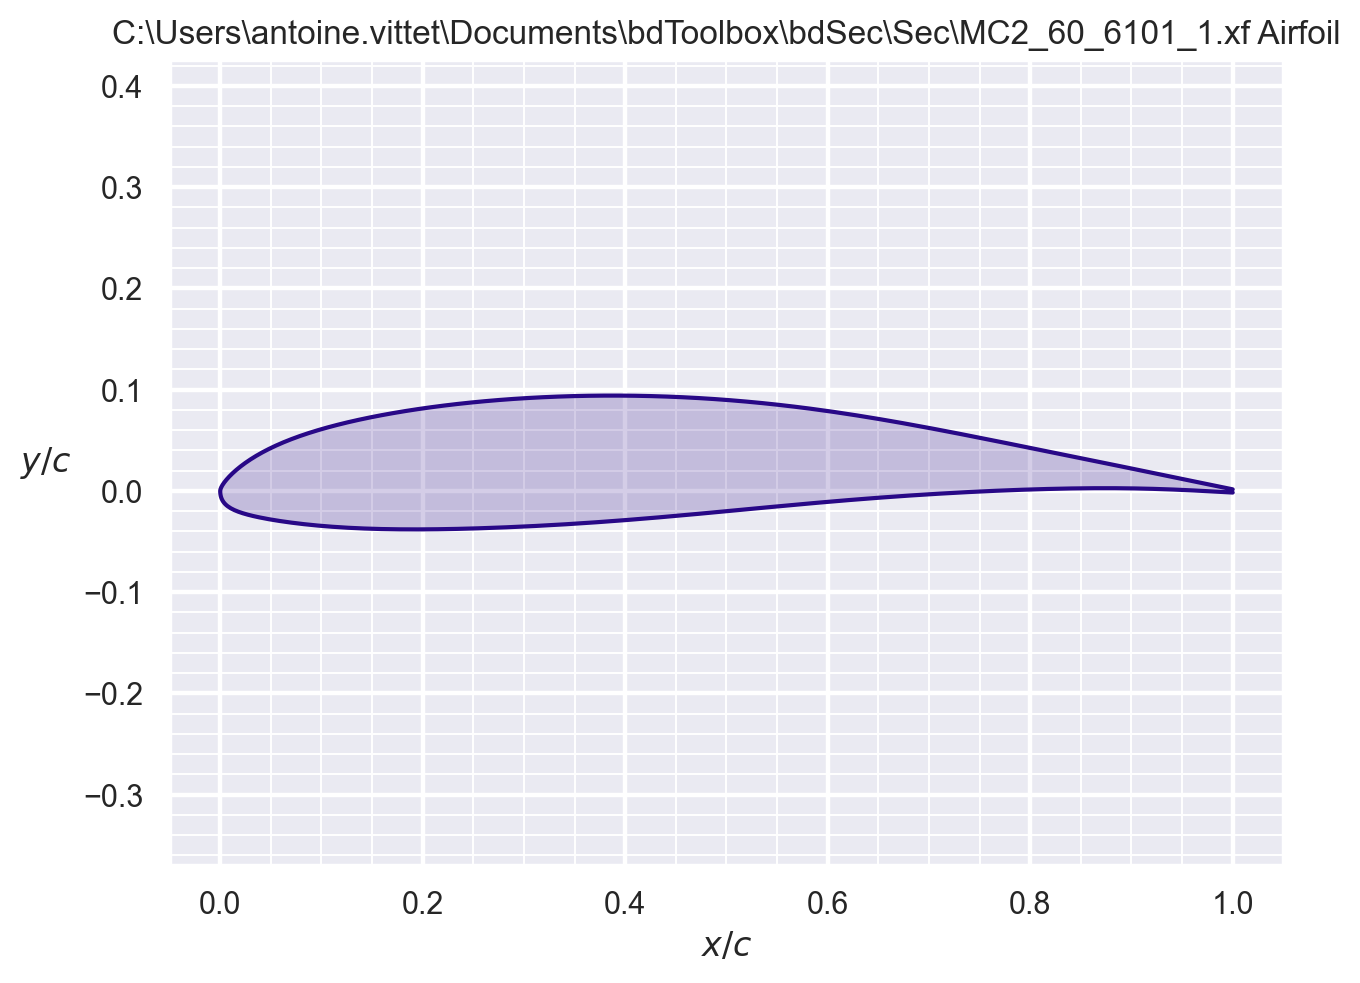

In [2]:
# Load as Airfoil first to fix coordinate ordering, then convert to KulfanAirfoil
# C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\bdSec\\Sec\\MC2_60_6101_1.xf
_mc2_coord = asb.Airfoil("C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\bdSec\\Sec\\MC2_60_6101_1.xf")

_mc2_coord.coordinates = _mc2_coord.coordinates[::-1]
mc2_init = _mc2_coord.to_kulfan_airfoil()
mc2_init.draw()

In [3]:
from pprint import pprint  # "pretty print"

pprint(mc2_init.kulfan_parameters)

{'TE_thickness': np.float64(0.003166887882193502),
 'leading_edge_weight': np.float64(0.7045622343245427),
 'lower_weights': array([-0.22986133, -0.32301684,  0.11918307, -0.29480874,  0.13723682,
       -0.11368593,  0.07576164,  0.05258067]),
 'upper_weights': array([0.09151442, 0.04615369, 0.38984212, 0.10536594, 0.40115153,
       0.17512155, 0.24224908, 0.20347439])}


In [4]:
print('centroid:', mc2_init.centroid())
print('Ixx:', mc2_init.Ixx())
print('Iyy:', mc2_init.Iyy())
print('Ixy:', mc2_init.Ixy())
print('J_centroid:', mc2_init.J_centroid())
print('max_thickness:', mc2_init.max_thickness())
print('max_camber:', mc2_init.max_camber())
print('local_thickness(0.9):', mc2_init.local_thickness(0.4))

centroid: [0.40373257 0.02633233]
Ixx: 8.001691868282087e-05
Iyy: 0.0040843767912160794
Ixy: 7.13009381826977e-05
J_centroid: 0.004164393709898901
max_thickness: 0.1267761133873195
max_camber: 0.035067072904474084
local_thickness(0.9): 0.1229480214009306


In [5]:
print('TE_thickness:', mc2_init.local_thickness(x_over_c=0.999))

TE_thickness: 0.0033146505785537203


## Section optimization for IntensSY

We will first start from a cambered NACA4412 airfoil and run an optimization of the section. The performances will be evaluated against the MC2_60 section designed by Michel Kermarec.

We will then run an optimization starting from the MC2_60 section to check if the optimizer finds a better solution.

*(See 02 - NeuralFoil Optimization.ipynb for the template and more explanations)*

**Objective**: Minimize $C_{D, \mathrm{mean}}$

**Variables** :
* Airfoil shape with the 8 Kulfan parameters

**Design constraints**:

* We first try with a section producing at least the same Cl at $[0,1,2,3,4,5,6]°$ of AOA as MC2_section (this could be changed later on if we see in the VPP that we need more or less lift force) \
--> **Cl_IntensSY (alpha = $[0,1,2,3,4,5,6]°$) $\geq$ Cl_MC2_60 (alpha = $[0,1,2,3,4,5,6]°$)**

* We want to at least maintain the structural properties of the section
    * In a first approximation we maintain Ixx which is the most significant in bending stiffness (this is what D3 kept as a constant for section optim of Mobyfly as well). And J = Ixx + Iyy \
    --> **Ixx_IntensSY $\geq$ Ixx_MC2_60**\
    --> **J_centroid_IntensSY $\geq$ J_centroid_MC2_60**
    * We could also impose a relative thickness (t/c) at a chord location, a max thickness, a min area (torsional stiffness)

We will also add some "regularization" constraints that tend to make airfoil optimization better-behaved by ruling out non-physical and unrealistic airfoils. It turns out that in this simple airfoil optimization case, these are not necessary and the optimizer will converge regardless. However, they are demonstrated here as they are "best practices" for airfoil optimization on more complicated problems:

* The first such constraint is that the airfoil thickness must be positive everywhere. This is implemented as `optimized_airfoil.local_thickness() > 0`. This prevents the creation of self-intersecting airfoils, which can be analyzed in both XFoil and NeuralFoil, but are obviously not physically-valid shapes.

* The second such constraint is that the `"analysis_confidence"` reported by NeuralFoil analysis must be greater than 0.90. This ensures that the airfoil isn't operating in a regime with excessively delicate boundary layer behavior, which can be difficult to predict and can lead to poor performance in practice.

* The third such constraint aims to guide the optimizer away from airfoils that are excessively "wiggly", as these have boundary layer behavior that is quite difficult to predict. Our measure of the "wiggliness" of an airfoil, $w$, is based on the same metric that has successfully been used for decades in univariate spline regularization (See: [Wahba, Grace, "Spline Models for Observational Data"](https://epubs.siam.org/doi/book/10.1137/1.9781611970128)):

$$w(\mathrm{airfoil}) = \int_0^1 \left( \frac{d^2}{dx^2} y_\mathrm{lower}(x) \right)^2 + \left( \frac{d^2}{dx^2} y_\mathrm{upper}(x) \right)^2 dx$$

We can approximate this wiggliness $w$ in a discrete sense as:

$$w(\mathrm{airfoil}) \approx \sum_{i=2}^{N-1} \left(c_{\mathrm{lower},i+1} - 2 \cdot c_{\mathrm{lower},i} + c_{\mathrm{lower},i-1} \right)^2 + \left(c_{\mathrm{upper},i+1} - 2 \cdot c_{\mathrm{upper},i} + c_{\mathrm{upper},i-1} \right)^2$$

Where $c_{\mathrm{lower},i}$ and $c_{\mathrm{upper},i}$ are the $i$th Kulfan (CST) coefficients of the lower and upper surfaces, respectively. Note that a $dx^2$-like constant has been dropped, so really this discrete approximation is just a proportionality.

We constrain this wiggliness $w$ to be no more than 4 times that of the initial guess airfoil, which is a reasonable heuristic that tends to work well in practice.

* The fourth are constraints on the upper and lower bounds of the weights to avoid doing a too cambered/weird profile


Also note the optimization settings passed into IPOPT (the underlying solver) with opti.solve():
* `mu_strategy` -> "monotone": This is a heuristic that tends to result in more robust convergence on highly nonconvex problems. On convex problems and larger problems, the default setting ("adaptive") tends to result in faster convergence.
* `start_with_resto` -> "yes": This is another heuristic that tells the optimizer to focus on finding the feasible space initially. This can be good when you know your initial guess is very far from satisfying all constraints.

If you have convergence trouble with airfoil optimization, try adding these options (as demonstrated below).

## Starting with a NACA 2412 airfoil

In [6]:
### Operating conditions
alphas_op = np.array([0, 2, 4, 6, 8, 10, 12])  # fixed operating points [deg]
Re = 1e6

### MC2_60 reference aero at operating points
mc2_aero = mc2_init.get_aero_from_neuralfoil(
    alpha=alphas_op,
    Re=Re,
    mach=0.01,
)

### Initial guess
initial_guess_airfoil = asb.KulfanAirfoil("naca2412")
initial_guess_airfoil.name = "Initial Guess (NACA2412)"

### Optimization setup
opti = asb.Opti()

optimized_airfoil = asb.KulfanAirfoil(
    name="Optimized",
    lower_weights=opti.variable(
        init_guess=initial_guess_airfoil.lower_weights,
        lower_bound=-0.5,
        upper_bound=0.25,
    ),
    upper_weights=opti.variable(
        init_guess=initial_guess_airfoil.upper_weights,
        lower_bound=-0.25,
        upper_bound=0.5,
    ),
    leading_edge_weight=opti.variable(
        init_guess=initial_guess_airfoil.leading_edge_weight,
        lower_bound=-1,
        upper_bound=1,
    ),
    TE_thickness=mc2_init.local_thickness(x_over_c=0.999),
)

aero = optimized_airfoil.get_aero_from_neuralfoil(
    alpha=alphas_op,
    Re=Re,
    mach=0.01,
)

### Constraints
opti.subject_to(
    [
        # Aerodynamic: CL >= MC2_60 at all operating alphas
        aero["CL"] >= mc2_aero["CL"],
        aero["analysis_confidence"] > 0.90,
        # Structural: maintain bending & torsional stiffness
        optimized_airfoil.Ixx() >= mc2_init.Ixx(),
        optimized_airfoil.Ixx() + optimized_airfoil.Iyy() >= mc2_init.Ixx() + mc2_init.Iyy(),  # J_centroid
        # Regularization
        optimized_airfoil.lower_weights[0] < -0.05, # Ensure the lower surface goes downward at the leading edge
        optimized_airfoil.upper_weights[0] > 0.05, # Ensure the upper surface goes upward at the leading edge
        optimized_airfoil.local_thickness() > 0,
    ]
)

get_wiggliness = lambda af: sum(
    [
        np.sum(np.diff(np.diff(array)) ** 2)
        for array in [af.lower_weights, af.upper_weights]
    ]
)

opti.subject_to(
    get_wiggliness(optimized_airfoil) < 2 * get_wiggliness(initial_guess_airfoil)
)

### Objective: minimize mean drag
opti.minimize(np.mean(aero["CD"]))

sol = opti.solve(
    behavior_on_failure="return_last",
    options={"ipopt.mu_strategy": "monotone", "ipopt.start_with_resto": "yes"},
)

optimized_airfoil = sol(optimized_airfoil)
aero = sol(aero)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:     2041
Number of nonzeros in Lagrangian Hessian.............:      153

Total number of variables............................:       17
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:      154
        inequality constraints with only lower bounds:      135
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       19

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0906832e-02 2.35e-01 4.40e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [7]:
### Operating conditions
CL_multipoint_targets = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
CL_multipoint_weights = np.array([2, 2, 3, 3, 3, 2, 2])  # Heavier weighting on mid-range CLs where typical cruise operates
Re = 1e6

### MC2_60 reference CL at alpha=0
mc2_aero_0 = mc2_init.get_aero_from_neuralfoil(
    alpha=0,
    Re=Re,
    mach=0.01,
)

### Initial guess
initial_guess_airfoil = asb.KulfanAirfoil("naca2412")
initial_guess_airfoil.name = "Initial Guess (NACA2412)"

### Optimization setup
opti = asb.Opti()

optimized_airfoil = asb.KulfanAirfoil(
    name="Optimized",
    lower_weights=opti.variable(
        init_guess=initial_guess_airfoil.lower_weights,
        lower_bound=-0.5,
        upper_bound=0.25,
    ),
    upper_weights=opti.variable(
        init_guess=initial_guess_airfoil.upper_weights,
        lower_bound=-0.25,
        upper_bound=0.5,
    ),
    leading_edge_weight=opti.variable(
        init_guess=initial_guess_airfoil.leading_edge_weight,
        lower_bound=-1,
        upper_bound=1,
    ),
    TE_thickness=mc2_init.local_thickness(x_over_c=0.999),
)

### Aero at alpha=0 (fixed) for CL equality constraint
aero_0 = optimized_airfoil.get_aero_from_neuralfoil(
    alpha=0,
    Re=Re,
    mach=0.01,
)

### Multipoint: alpha is a variable vector, solver adjusts to hit CL targets
alpha_mp = opti.variable(
    init_guess=np.degrees(CL_multipoint_targets / (2 * np.pi)),
    lower_bound=-5,
    upper_bound=18,
)

aero_mp = optimized_airfoil.get_aero_from_neuralfoil(
    alpha=alpha_mp,
    Re=Re,
    mach=0.01,
)

### Constraints
opti.subject_to(
    [
        # Aerodynamic: match MC2_60 CL at alpha=0
        aero_0["CL"] >= mc2_aero_0["CL"],
        aero_0["analysis_confidence"] > 0.90,
        # Multipoint: hit CL targets, ensure monotonic alpha
        aero_mp["CL"] == CL_multipoint_targets,
        aero_mp["analysis_confidence"] > 0.90,
        np.diff(alpha_mp) > 0,
        # Structural: maintain bending & torsional stiffness
        optimized_airfoil.Ixx() >= mc2_init.Ixx(),
        optimized_airfoil.Ixx() + optimized_airfoil.Iyy() >= mc2_init.Ixx() + mc2_init.Iyy(),  # J_centroid
        optimized_airfoil.local_thickness(x_over_c=0.9) >= mc2_init.local_thickness(x_over_c=0.9),  # Ensure tip thickness is enough
        optimized_airfoil.local_thickness(x_over_c=0.95) >= mc2_init.local_thickness(x_over_c=0.95), # Ensure tip thickness is enough
        # Regularization
        optimized_airfoil.lower_weights[0] < -0.05, # Ensure the lower surface goes downward at the leading edge
        optimized_airfoil.upper_weights[0] > 0.05, # Ensure the upper surface goes upward at the leading edge
        optimized_airfoil.local_thickness() > 0,
    ]
)

get_wiggliness = lambda af: sum(
    [
        np.sum(np.diff(np.diff(array)) ** 2)
        for array in [af.lower_weights, af.upper_weights]
    ]
)

opti.subject_to(
    get_wiggliness(optimized_airfoil) < 2 * get_wiggliness(initial_guess_airfoil)
)

### Objective: minimize weighted mean drag at multipoint targets
opti.minimize(np.sum(aero_mp["CD"] * CL_multipoint_weights) / np.sum(CL_multipoint_weights))

sol = opti.solve(
    behavior_on_failure="return_last",
    options={"ipopt.mu_strategy": "monotone", "ipopt.start_with_resto": "yes"},
)

optimized_airfoil = sol(optimized_airfoil)
aero_mp = sol(aero_mp)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      126
Number of nonzeros in inequality constraint Jacobian.:     2023
Number of nonzeros in Lagrangian Hessian.............:      279

Total number of variables............................:       24
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        7
Total number of inequality constraints...............:      171
        inequality constraints with only lower bounds:      145
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       26

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  9.8167123e-03 2.54e-01 6.17e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

## Result comparison

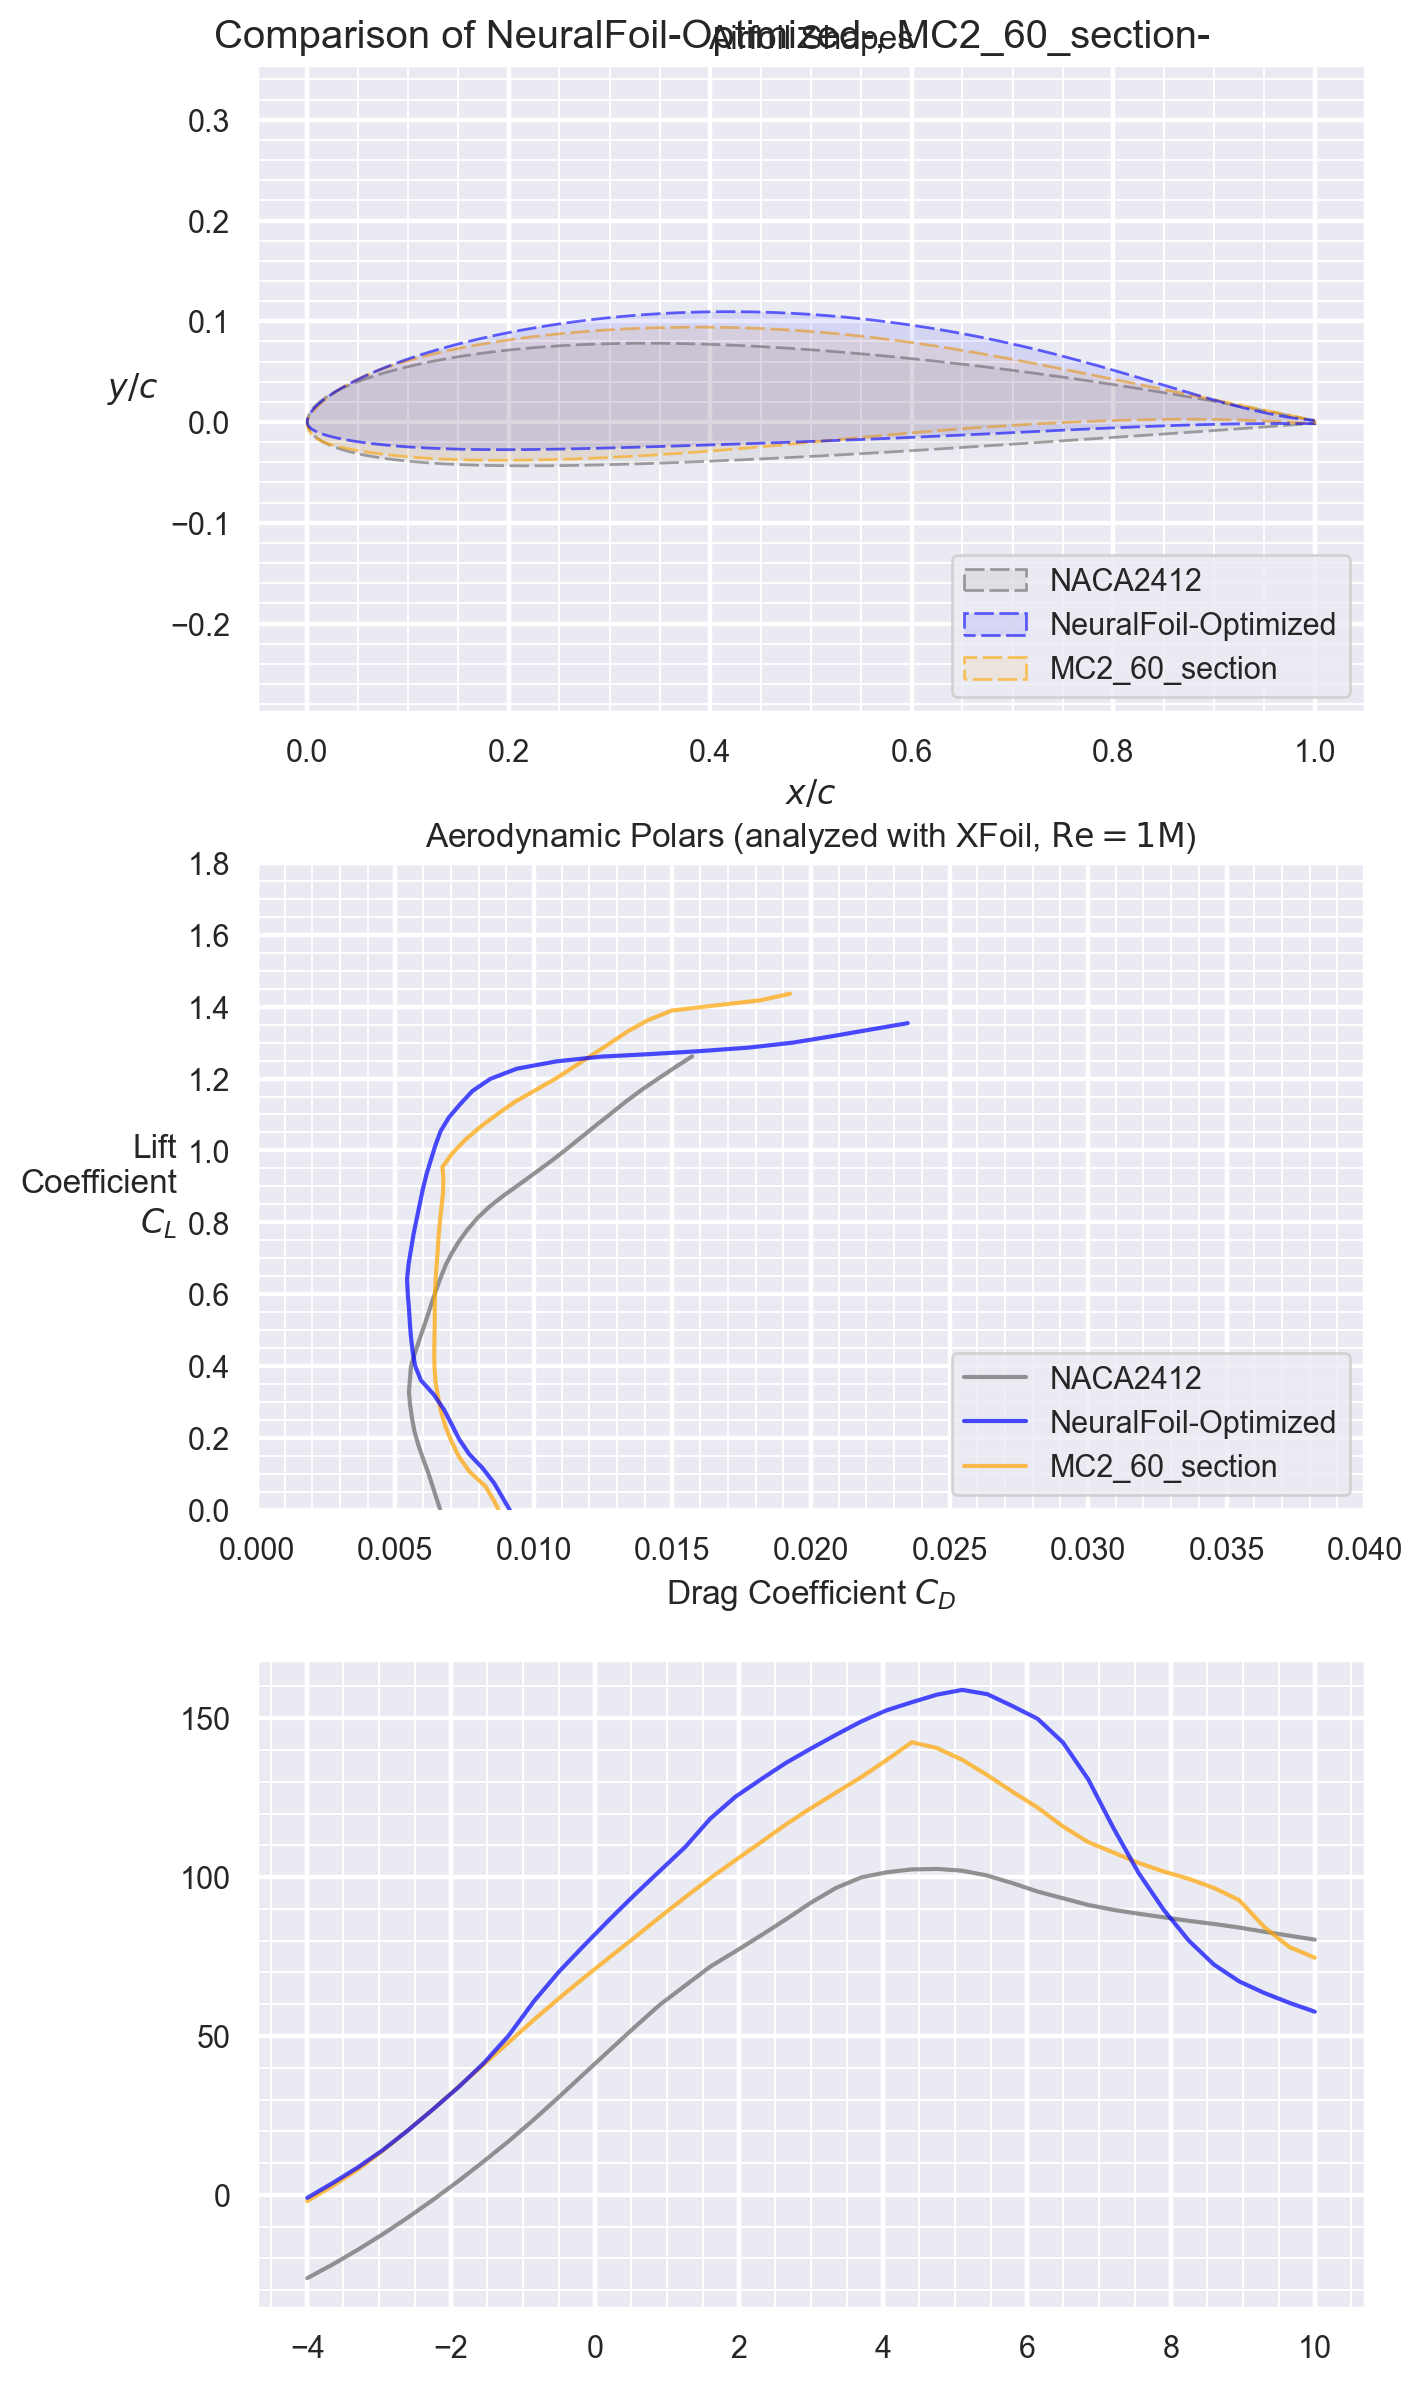

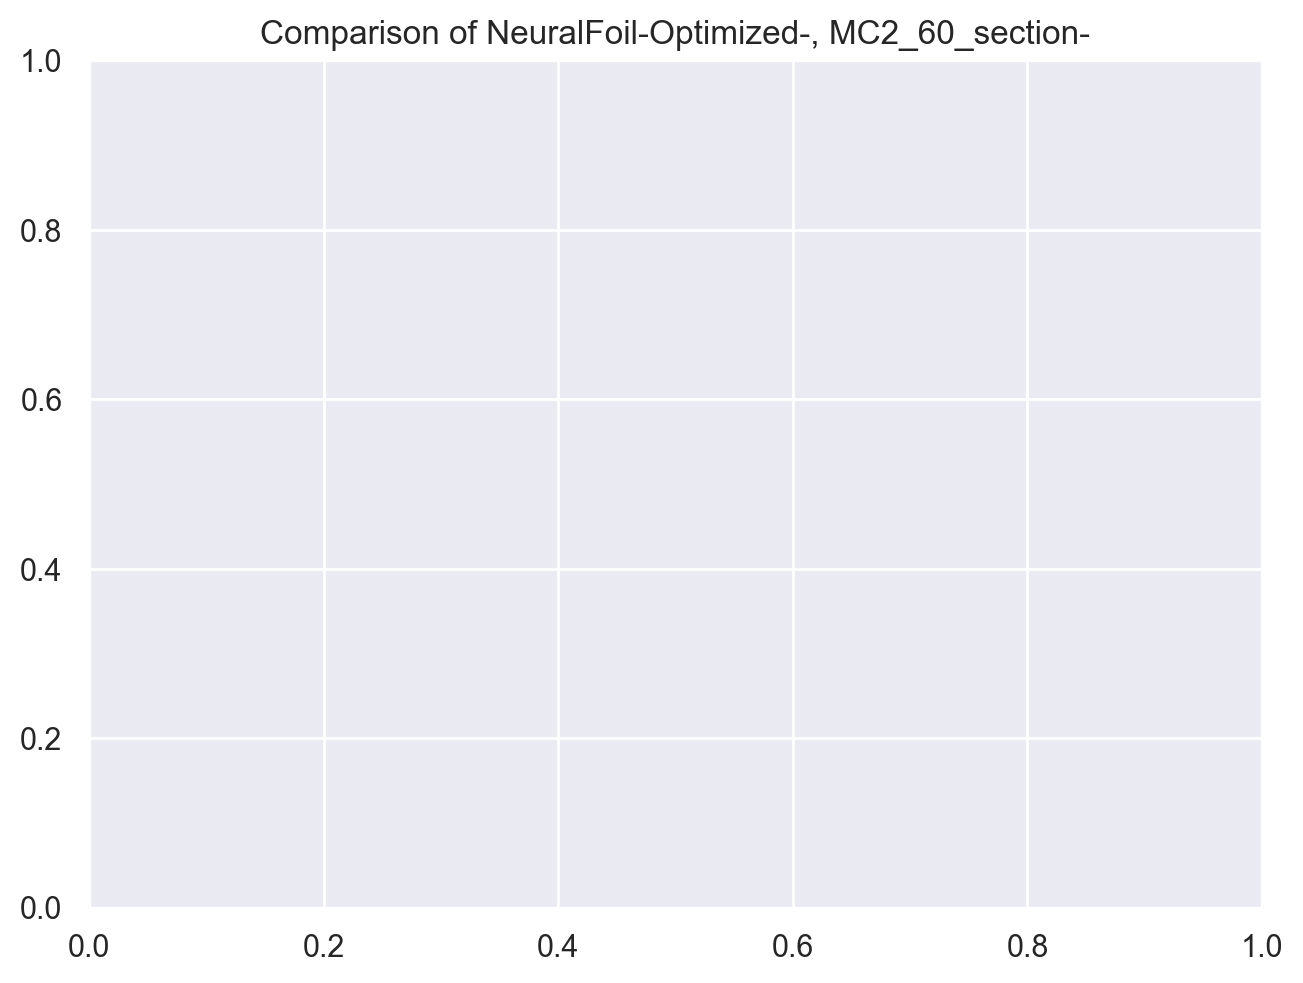

In [9]:
# NBVAL_SKIP

import matplotlib.pyplot as plt

Re_plot = 1e6

fig, ax = plt.subplots(3, 1, figsize=(7, 12))

airfoils_and_colors = {
    "NACA2412": (initial_guess_airfoil, "dimgray"),
    "NeuralFoil-Optimized": (optimized_airfoil, "blue"),
    "MC2_60_section": (mc2_init, "orange"),
}

for i, (name, (af, color)) in enumerate(airfoils_and_colors.items()):
    color = p.adjust_lightness(color, 1)
    ax[0].fill(
        af.x(),
        af.y(),
        facecolor=(*color, 0.09),
        edgecolor=(*color, 0.6),
        linewidth=1,
        label=name,
        linestyle=(3 * i, (7, 2)),
        zorder=4 if "NeuralFoil" in name else 3,
    )
    # aero = af.get_aero_from_neuralfoil(
    #     alpha=np.linspace(0, 15, 500),
    #     Re=Re,
    #     mach=mach,
    # )

    aero = asb.XFoil(
        airfoil=af,
        Re=Re_plot,
        mach=0.01,
        xfoil_command = "C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe", # C:\\Users\\antoi\\Documents\\Banulsdesign\\bdToolbox\\soft\\xfoil.exe #C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe
        timeout=30,
    ).alpha(np.linspace(-4, 10, 41), start_at=5)
    ax[1].plot(
        aero["CD"],
        aero["CL"],  # "--",
        color=color,
        alpha=0.7,
        label=name,
        zorder=4 if "NeuralFoil" in name else 3,
    )

    ax[2].plot(
        aero["alpha"],
        aero["CL"]/aero["CD"],
        color=color,
        alpha=0.7,
        label=name,
        zorder=4 if "NeuralFoil" in name else 3,
    )
ax[0].legend(fontsize=11, loc="lower right", ncol=len(airfoils_and_colors) // 2)
ax[0].set_title("Airfoil Shapes")
ax[0].set_xlabel("$x/c$")
ax[0].set_ylabel("$y/c$")
ax[0].axis("equal")

ax[1].legend(fontsize=11, loc="lower right", ncol=len(airfoils_and_colors) // 2)
ax[1].set_title(
    "Aerodynamic Polars (analyzed with XFoil, $\\mathrm{Re}=1\\mathrm{M}$)"
)
ax[1].set_xlabel("Drag Coefficient $C_D$")
ax[1].set_ylabel("Lift\nCoefficient\n$C_L$")
ax[1].set_xlim(0, 0.04)
ax[1].set_ylim(0, 1.8)
p.show_plot(
    "Comparison of NeuralFoil-Optimized-, MC2_60_section-",
    legend=False,
)

ax[2].legend(fontsize=11, loc="lower right", ncol=len(airfoils_and_colors) // 2)
ax[2].set_title(
    "Lift-to-Drag Ratio vs. Angle of Attack (analyzed with XFoil, $\\mathrm{Re}=1\\mathrm{M}$)"
)
ax[2].set_xlabel("Angle of Attack $\\alpha$ [deg]")
ax[2].set_ylabel("Lift-to-Drag Ratio\n$C_L/C_D$")
ax[2].set_xlim(-4, 10)
ax[2].set_ylim(0, 50)
p.show_plot(
    "Comparison of NeuralFoil-Optimized-, MC2_60_section-",
    legend=False,
)

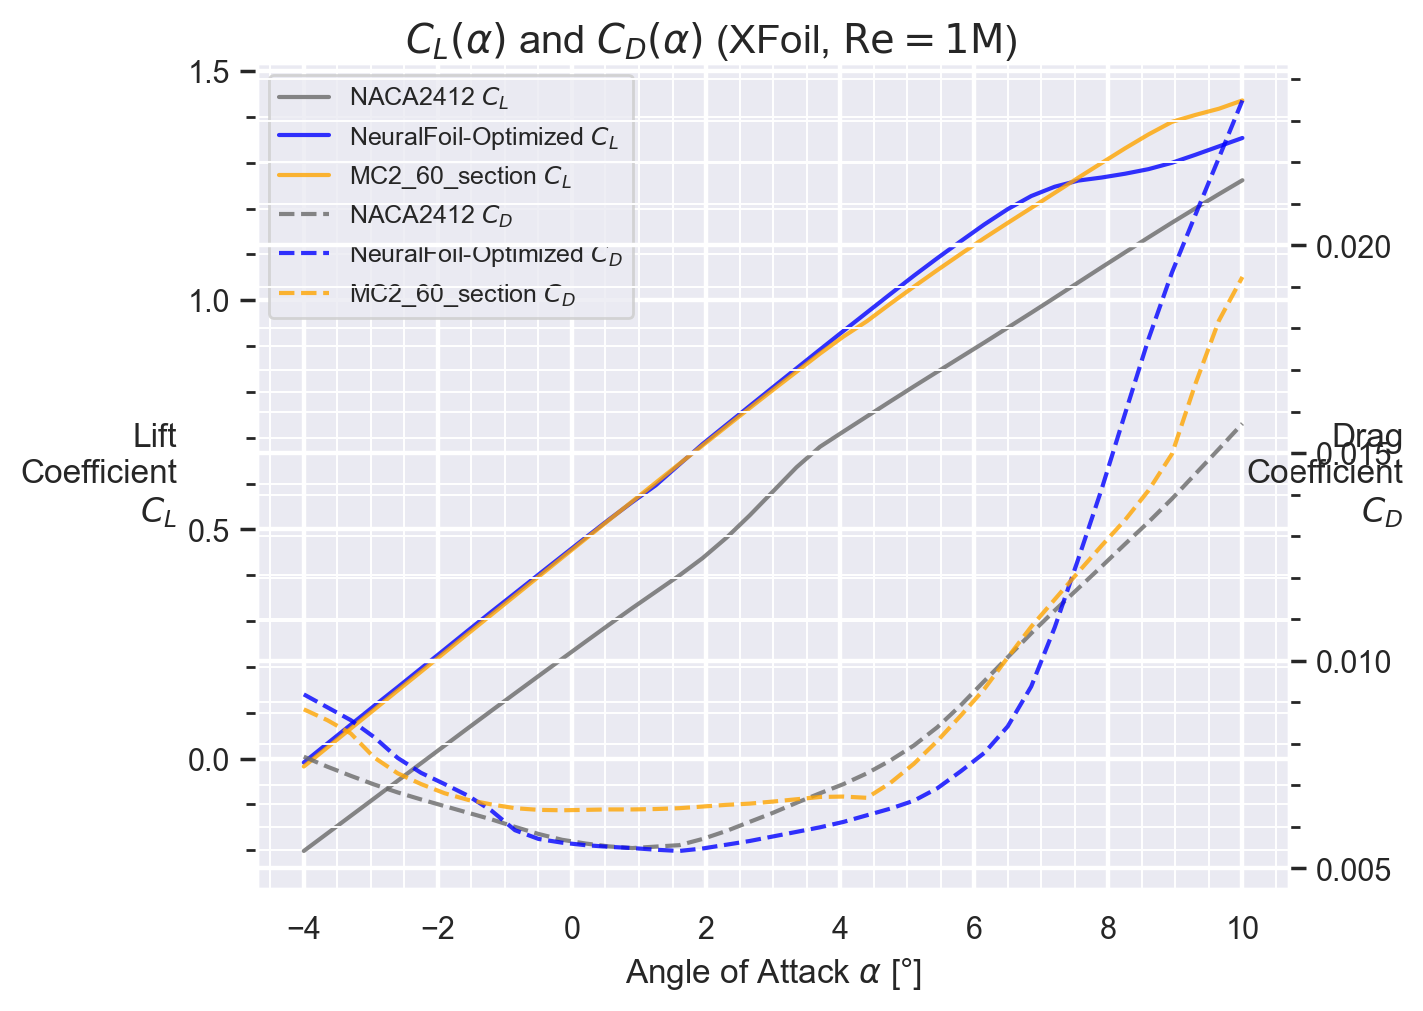

In [11]:
# NBVAL_SKIP

fig, ax1 = plt.subplots(figsize=(7, 5))

alphas_plot = np.linspace(-4, 10, 41)

for name, (af, color) in airfoils_and_colors.items():
    aero_plot = asb.XFoil(
        airfoil=af,
        Re=Re_plot,
        mach=0.01,
        xfoil_command = "C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe", # C:\\Users\\antoi\\Documents\\Banulsdesign\\bdToolbox\\soft\\xfoil.exe #C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe
        timeout=30,
    ).alpha(alphas_plot, start_at=5)

    ax1.plot(
        aero_plot["alpha"],
        aero_plot["CL"],
        "-",
        color=color,
        alpha=0.8,
        label=f"{name} $C_L$",
    )

ax1.set_xlabel(r"Angle of Attack $\alpha$ [°]")
ax1.set_ylabel("Lift Coefficient $C_L$")

ax2 = ax1.twinx()

for name, (af, color) in airfoils_and_colors.items():
    aero_plot = asb.XFoil(
        airfoil=af,
        Re=Re_plot,
        mach=0.01,
        xfoil_command = "C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe", # C:\\Users\\antoi\\Documents\\Banulsdesign\\bdToolbox\\soft\\xfoil.exe #C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe
        timeout=30,
    ).alpha(alphas_plot, start_at=5)

    ax2.plot(
        aero_plot["alpha"],
        aero_plot["CD"],
        "--",
        color=color,
        alpha=0.8,
        label=f"{name} $C_D$",
    )

ax2.set_ylabel("Drag Coefficient $C_D$")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

p.show_plot(
    r"$C_L(\alpha)$ and $C_D(\alpha)$ (XFoil, $\mathrm{Re}=1\mathrm{M}$)",
    legend=False,
)

In [ ]:
# NBVAL_SKIP
# --- Center of effort (center of pressure) along the chord ---
#   Primary (course convention): x_cp/c = -C_m,LE / C_l,  C_m,LE = C_m,c/4 - 0.25*C_l
#   Overlay (exact):             x_cp/c = 0.25 - C_m,c/4 / CN,  CN = CL*cos a + CD*sin a
import numpy as np
import matplotlib.pyplot as plt

Re_cop = 1e6
xfoil_cmd = "C:\\Users\\antoine.vittet\\Documents\\bdToolbox\\soft\\xfoil.exe"

cop_airfoils = {
    "MC2_60_section": (mc2_init, "orange"),
    "NeuralFoil-Optimized": (optimized_airfoil, "blue"),
}
alphas_cop = np.linspace(0, 12, 25)          # operating range; denominator > 0 here
alphas_table = np.array([0, 2, 4, 6, 8, 10, 12])

def x_cp_course(aero):                        # -C_m,LE / C_l  (lift, LE reference)
    Cl = aero["CL"]
    Cm_LE = aero["CM"] - 0.25 * Cl            # transfer c/4 -> LE
    return np.where(np.abs(Cl) < 0.1, np.nan, -Cm_LE / Cl)

def x_cp_exact(aero, alpha_deg):              # 0.25 - C_m,c/4 / CN  (normal force)
    a = np.radians(alpha_deg)
    CN = aero["CL"] * np.cos(a) + aero["CD"] * np.sin(a)
    return np.where(np.abs(CN) < 0.1, np.nan, 0.25 - aero["CM"] / CN)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
table_rows = []
for name, (af, color) in cop_airfoils.items():
    # NeuralFoil (consistent with the optimization)
    nf = af.get_aero_from_neuralfoil(alpha=alphas_cop, Re=Re_cop, mach=0.01)
    ax[0].plot(alphas_cop, x_cp_course(nf), "-",  color=color, label=f"{name} (NeuralFoil, course)")
    ax[0].plot(alphas_cop, x_cp_exact(nf, alphas_cop), ":", color=color, alpha=0.5,
               label=f"{name} (NeuralFoil, exact CN)")
    ax[1].plot(nf["CL"], x_cp_course(nf), "-", color=color, label=f"{name} (NeuralFoil)")

    # XFoil (viscous reference, matches the polar plots above)
    xf = asb.XFoil(airfoil=af, Re=Re_cop, mach=0.01,
                   xfoil_command=xfoil_cmd, timeout=30).alpha(alphas_cop, start_at=5)
    ax[0].plot(xf["alpha"], x_cp_course(xf), "--", color=color, label=f"{name} (XFoil, course)")
    ax[1].plot(xf["CL"], x_cp_course(xf), "--", color=color, label=f"{name} (XFoil)")

    # Table at operating alphas (NeuralFoil)
    nf_t = af.get_aero_from_neuralfoil(alpha=alphas_table, Re=Re_cop, mach=0.01)
    xcp_c = x_cp_course(nf_t)
    xcp_e = x_cp_exact(nf_t, alphas_table)
    for a_deg, cl, cm, xc, xe in zip(alphas_table, nf_t["CL"], nf_t["CM"], xcp_c, xcp_e):
        table_rows.append((name, a_deg, cl, cm, xc, xe))

for a in ax:
    a.axhline(0.25, color="k", lw=0.8, ls=":", label="quarter-chord")
    a.grid(alpha=0.3); a.legend(fontsize=7)
ax[0].set_xlabel(r"$\alpha$ [deg]"); ax[0].set_ylabel(r"$x_{cp}/c$ (from LE)")
ax[0].set_title(r"Center of effort vs. $\alpha$   ($x_{cp}/c=-C_{m,LE}/C_l$)")
ax[1].set_xlabel(r"$C_L$"); ax[1].set_ylabel(r"$x_{cp}/c$ (from LE)")
ax[1].set_title(r"Center of effort vs. $C_L$")
plt.tight_layout(); plt.show()

print(f"{'Section':22s} {'a[deg]':>7s} {'CL':>7s} {'CM_c/4':>9s} {'xcp/c(course)':>14s} {'xcp/c(exact)':>13s}")
for name, a_deg, cl, cm, xc, xe in table_rows:
    print(f"{name:22s} {a_deg:7.1f} {cl:7.3f} {cm:9.4f} {xc:14.3f} {xe:13.3f}")

In [13]:
## Export airfoils in 3 formats: .xf (XFoil), .csv, .dxf
import os
import numpy as _np

try:
    import ezdxf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ezdxf"])
    import ezdxf

export_dir = os.path.join(os.getcwd(), "exports")
os.makedirs(export_dir, exist_ok=True)

airfoils_to_export = {
    "optimized_airfoil": optimized_airfoil,
    "MC2_60_section": mc2_init,
}

for airfoil_name, af in airfoils_to_export.items():
    coords_x = af.x()
    coords_y = af.y()

    # 1) XFoil .xf format (Selig format: name header + x y columns)
    xf_path = os.path.join(export_dir, f"{airfoil_name}.xf")
    with open(xf_path, "w") as f:
        f.write(f"{airfoil_name}\n")
        for xi, yi in zip(coords_x, coords_y):
            f.write(f"  {xi:.6f}  {yi:.6f}\n")
    print(f"Exported XFoil format : {xf_path}")

    # 2) CSV format
    csv_path = os.path.join(export_dir, f"{airfoil_name}.csv")
    _np.savetxt(csv_path, _np.column_stack([coords_x, coords_y]),
                delimiter=",", header="x,y", comments="")
    print(f"Exported CSV          : {csv_path}")

    # 3) DXF format (importable in Rhino / AutoCAD as DWG)
    dxf_path = os.path.join(export_dir, f"{airfoil_name}.dxf")
    doc = ezdxf.new()
    msp = doc.modelspace()
    points = [(float(xi), float(yi)) for xi, yi in zip(coords_x, coords_y)]
    msp.add_lwpolyline(points, close=True)
    doc.saveas(dxf_path)
    print(f"Exported DXF          : {dxf_path}")
    print()

print(f"All files saved in: {export_dir}")

Exported XFoil format : c:\Users\antoine.vittet\Documents\bdToolbox\AeroSandbox\tutorial\06 - Aerodynamics\02 - AeroSandbox 2D Aerodynamics Tools\exports\optimized_airfoil.xf
Exported CSV          : c:\Users\antoine.vittet\Documents\bdToolbox\AeroSandbox\tutorial\06 - Aerodynamics\02 - AeroSandbox 2D Aerodynamics Tools\exports\optimized_airfoil.csv
Exported DXF          : c:\Users\antoine.vittet\Documents\bdToolbox\AeroSandbox\tutorial\06 - Aerodynamics\02 - AeroSandbox 2D Aerodynamics Tools\exports\optimized_airfoil.dxf

Exported XFoil format : c:\Users\antoine.vittet\Documents\bdToolbox\AeroSandbox\tutorial\06 - Aerodynamics\02 - AeroSandbox 2D Aerodynamics Tools\exports\MC2_60_section.xf
Exported CSV          : c:\Users\antoine.vittet\Documents\bdToolbox\AeroSandbox\tutorial\06 - Aerodynamics\02 - AeroSandbox 2D Aerodynamics Tools\exports\MC2_60_section.csv
Exported DXF          : c:\Users\antoine.vittet\Documents\bdToolbox\AeroSandbox\tutorial\06 - Aerodynamics\02 - AeroSandbox 2D 